# 01 — EDA для Water Potability

**Цель ноутбука:** провести первичный анализ датасета Water Potability перед построением моделей.

Что проверяем:
- корректность загрузки данных;
- размерность, типы данных, дубликаты;
- пропуски;
- баланс целевой переменной `Potability`;
- распределения признаков;
- выбросы;
- различия признаков между классами;
- корреляции между признаками.

> В этом ноутбуке мы **не обучаем модели**. Задача EDA — понять данные и сформулировать практичные решения для preprocessing.

## 1. Импорт библиотек и базовые настройки

Импортируем библиотеки для работы с таблицами и визуализацией.  
Фиксируем стиль графиков и базовые параметры отображения, чтобы ноутбук был читаемым.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

**Что увидели / вывод:**  
На этом шаге мы только подготовили окружение. Все дальнейшие графики и таблицы будут строиться в едином стиле.

## 2. Загрузка данных

Ожидаем, что файл лежит по пути:

```text
../data/raw/water_potability.csv
```

Если у тебя другая структура проекта, поменяй переменную `DATA_PATH`.

In [4]:
DATA_PATH = Path("data/raw/water_potability.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890,20791.319,7.300,368.516,564.309,10.380,86.991,2.963,0
1,3.716,129.423,18630.058,6.635,NaN,592.885,15.180,56.329,4.501,0
2,8.099,224.236,19909.542,9.276,NaN,418.606,16.869,66.420,3.056,0
3,8.317,214.373,22018.417,8.059,356.886,363.267,18.437,100.342,4.629,0
4,9.092,181.102,17978.986,6.547,310.136,398.411,11.558,31.998,4.075,0


## 3. Базовые проверки: shape, dtypes, duplicates

In [5]:
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

display(df.dtypes.to_frame("dtype"))

duplicates_count = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")

display(df.describe().T)

Количество строк: 3276
Количество столбцов: 10


,dtype
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


Количество полных дубликатов: 0


,count,mean,std,min,25%,50%,75%,max
ph,2785.000,7.081,1.594,0.000,6.093,7.037,8.062,14.000
Hardness,3276.000,196.369,32.880,47.432,176.851,196.968,216.667,323.124
Solids,3276.000,22014.093,8768.571,320.943,15666.690,20927.834,27332.762,61227.196
Chloramines,3276.000,7.122,1.583,0.352,6.127,7.130,8.115,13.127
Sulfate,2495.000,333.776,41.417,129.000,307.699,333.074,359.950,481.031
Conductivity,3276.000,426.205,80.824,181.484,365.734,421.885,481.792,753.343
Organic_carbon,3276.000,14.285,3.308,2.200,12.066,14.218,16.558,28.300
Trihalomethanes,3114.000,66.396,16.175,0.738,55.845,66.622,77.337,124.000
Turbidity,3276.000,3.967,0.780,1.450,3.440,3.955,4.500,6.739
Potability,3276.000,0.390,0.488,0.000,0.000,0.000,1.000,1.000


**Что увидели / вывод:**  
Здесь нужно зафиксировать базовые факты о данных.  
Ожидаем, что все признаки числовые, а `Potability` — бинарная целевая переменная.  
Если есть дубликаты, их стоит удалить на этапе preprocessing. Если типы данных нечисловые — нужно отдельно разобраться, почему.

## 4. Проверка названий колонок и разделение признаков

Отделяем целевую переменную от признаков. Это удобно для дальнейшего анализа.

In [6]:
target_col = "Potability"

feature_cols = [col for col in df.columns if col != target_col]

print("Целевая переменная:", target_col)
print("Признаки:")
for col in feature_cols:
    print("-", col)

Целевая переменная: Potability
Признаки:
- ph
- Hardness
- Solids
- Chloramines
- Sulfate
- Conductivity
- Organic_carbon
- Trihalomethanes
- Turbidity


## 5. Анализ пропусков

Смотрим количество и долю пропущенных значений по каждой колонке.

,missing_count,missing_percent
Sulfate,781,23.840
ph,491,14.988
Trihalomethanes,162,4.945
Hardness,0,0.000
Solids,0,0.000
Chloramines,0,0.000
Conductivity,0,0.000
Organic_carbon,0,0.000
Turbidity,0,0.000
Potability,0,0.000


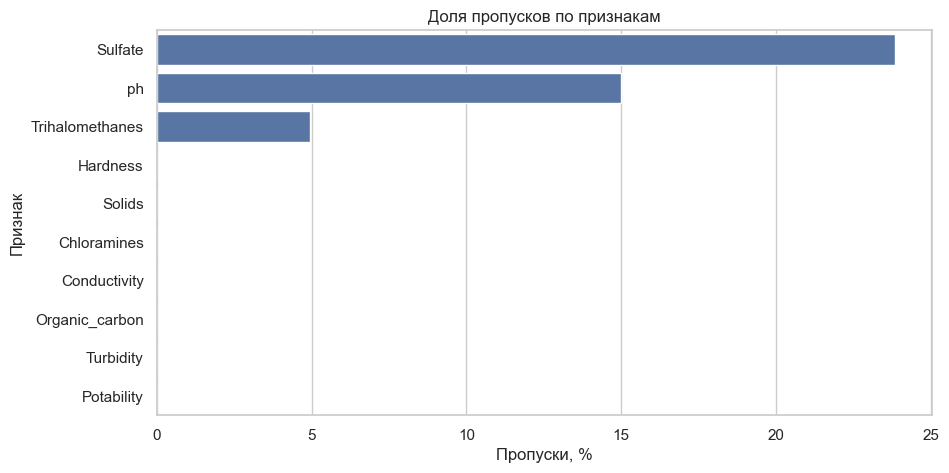

In [7]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_percent", ascending=False)
)

display(missing)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing.reset_index().rename(columns={"index": "feature"}),
    x="missing_percent",
    y="feature"
)
plt.title("Доля пропусков по признакам")
plt.xlabel("Пропуски, %")
plt.ylabel("Признак")
plt.show()

## 6. Пропуски в разрезе target

Проверяем, отличаются ли пропуски между классами `Potability = 0` и `Potability = 1`.

Это важно: если пропуски распределены неслучайно, сам факт пропуска может быть полезным сигналом для модели.

,Potability=0,Potability=1
ph,15.716,13.850
Hardness,0.000,0.000
Solids,0.000,0.000
Chloramines,0.000,0.000
Sulfate,24.424,22.926
Conductivity,0.000,0.000
Organic_carbon,0.000,0.000
Trihalomethanes,5.355,4.304
Turbidity,0.000,0.000


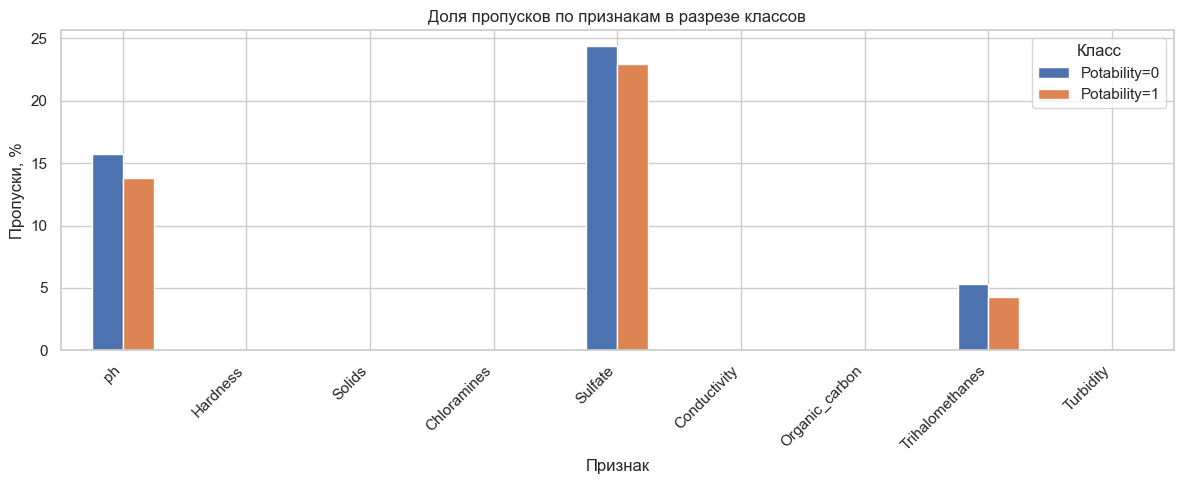

In [8]:
missing_by_target = (
    df.groupby(target_col)[feature_cols]
    .apply(lambda group: group.isna().mean() * 100)
    .T
)

missing_by_target.columns = [f"Potability={int(col)}" for col in missing_by_target.columns]

display(missing_by_target)

missing_by_target.plot(kind="bar", figsize=(12, 5))
plt.title("Доля пропусков по признакам в разрезе классов")
plt.ylabel("Пропуски, %")
plt.xlabel("Признак")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Класс")
plt.tight_layout()
plt.show()

## 7. Распределение целевой переменной

Проверяем баланс классов. Для бинарной классификации это влияет на выбор метрик и схему валидации.

,count,percent
Potability,,
0,1998,60.989
1,1278,39.011


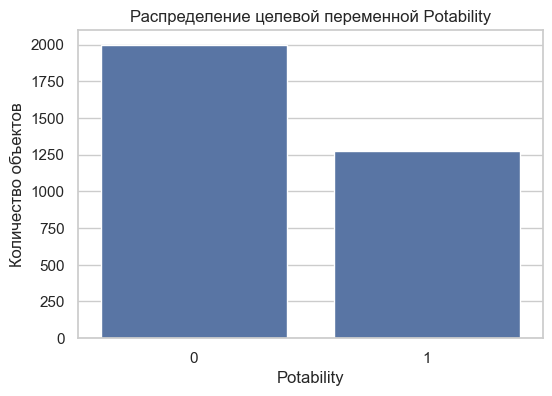

In [9]:
target_counts = df[target_col].value_counts().sort_index()
target_share = df[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_share
})

display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Распределение целевой переменной Potability")
plt.xlabel("Potability")
plt.ylabel("Количество объектов")
plt.show()

## 8. Распределения признаков: histplot

Строим гистограммы для всех числовых признаков.  
Цель — увидеть форму распределений, асимметрию, хвосты и возможные экстремальные значения.

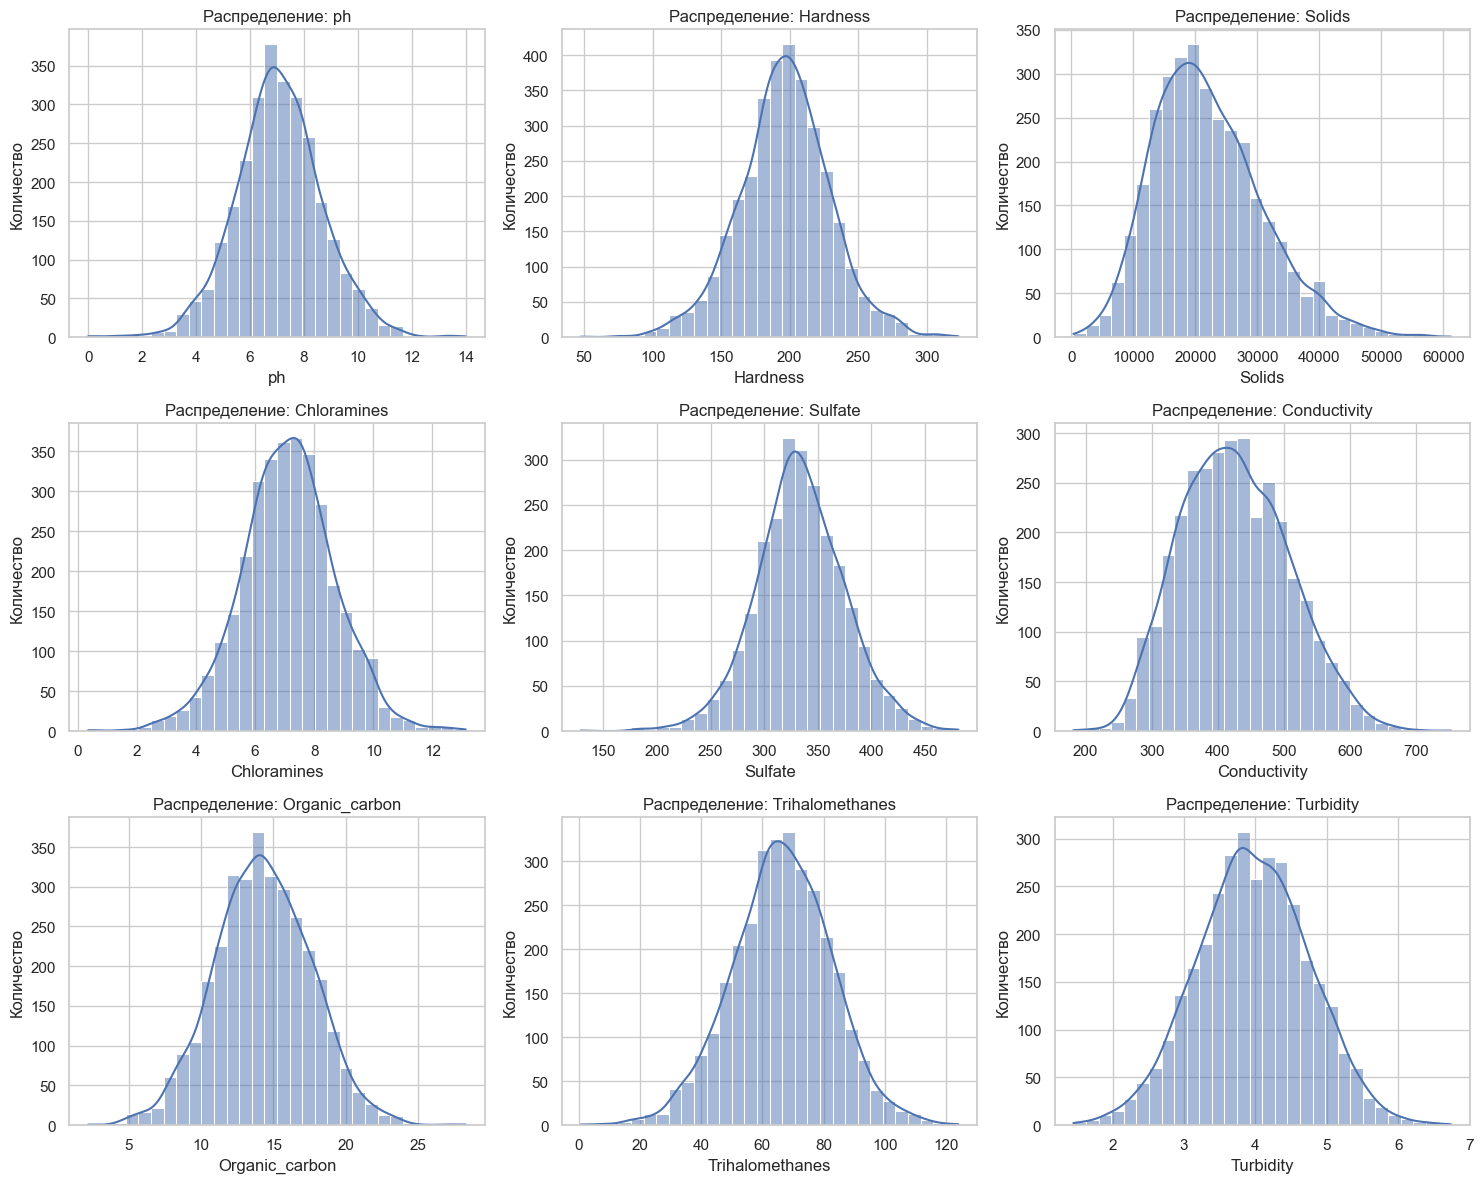

In [10]:
n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Распределение: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Количество")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Boxplot для поиска выбросов

Boxplot помогает быстро увидеть экстремальные значения и разброс признаков.

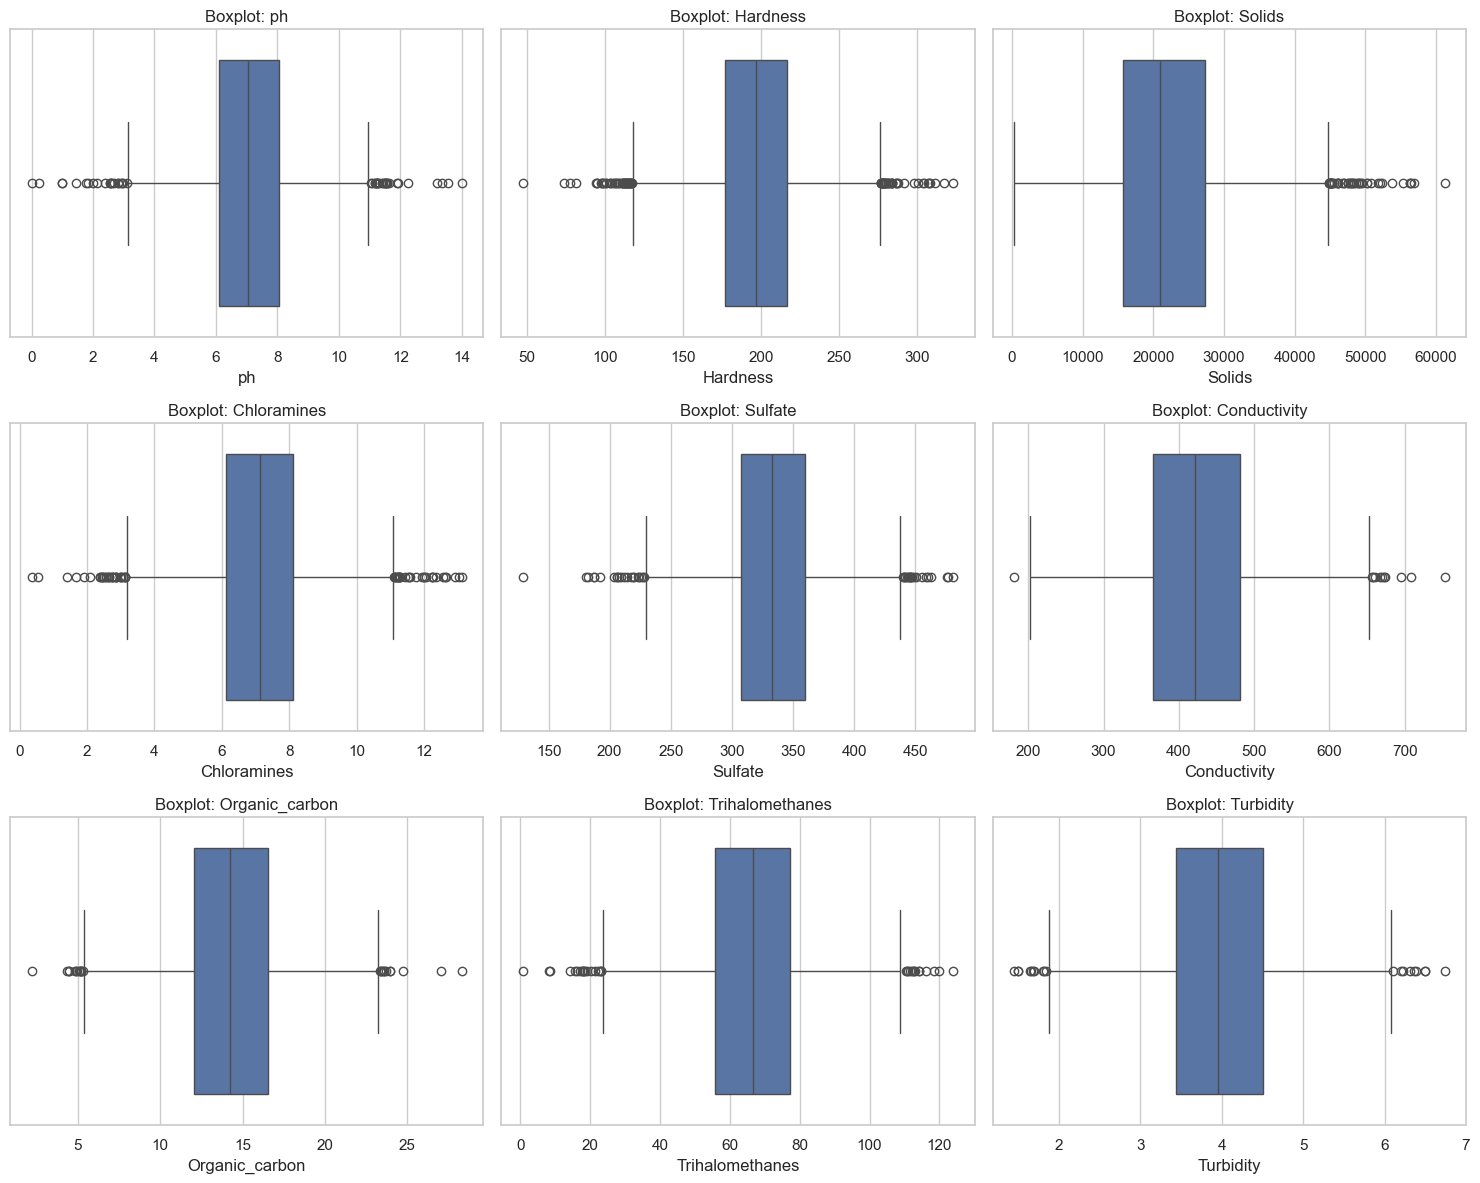

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 10. Сравнение признаков по классам: boxplot

Сравниваем распределения каждого признака отдельно для `Potability = 0` и `Potability = 1`.

Цель — понять, есть ли признаки, которые хотя бы частично разделяют классы.

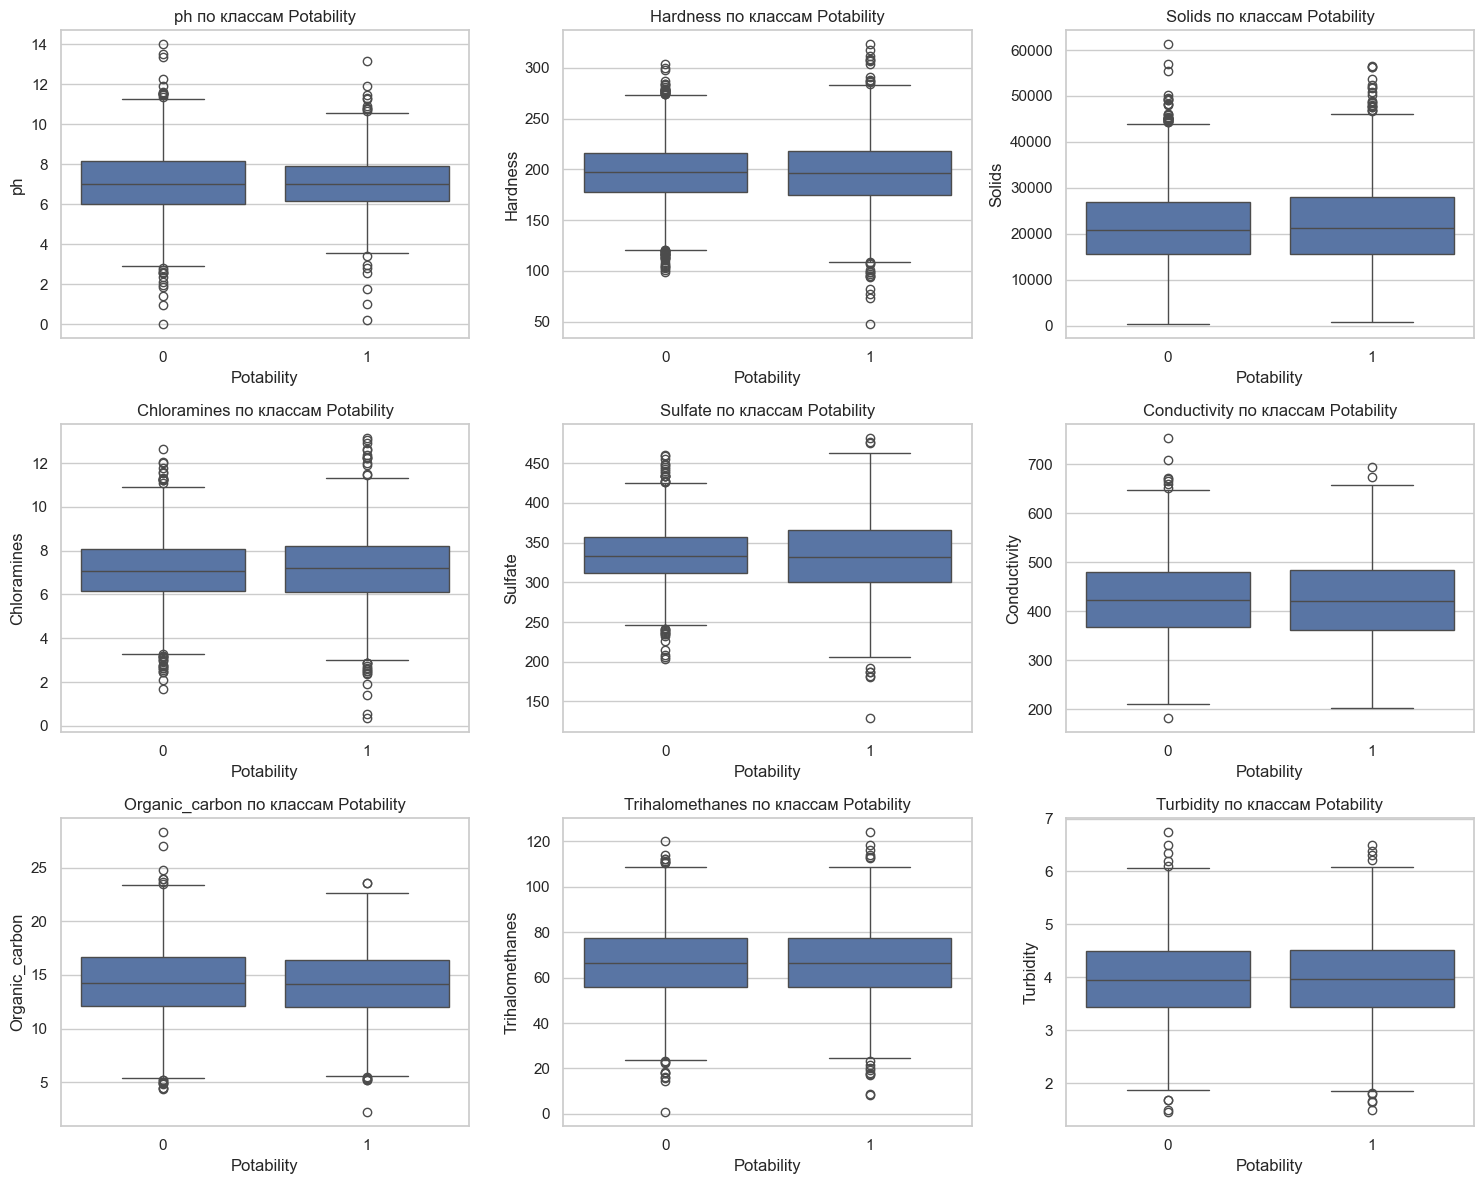

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()


for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i])
    axes[i].set_title(f"{col} по классам Potability")
    axes[i].set_xlabel("Potability")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Сравнение признаков по классам: histplot с hue

Дополнительно смотрим распределения признаков с разбивкой по классу.  
Это помогает увидеть различия не только по медиане, но и по форме распределения.

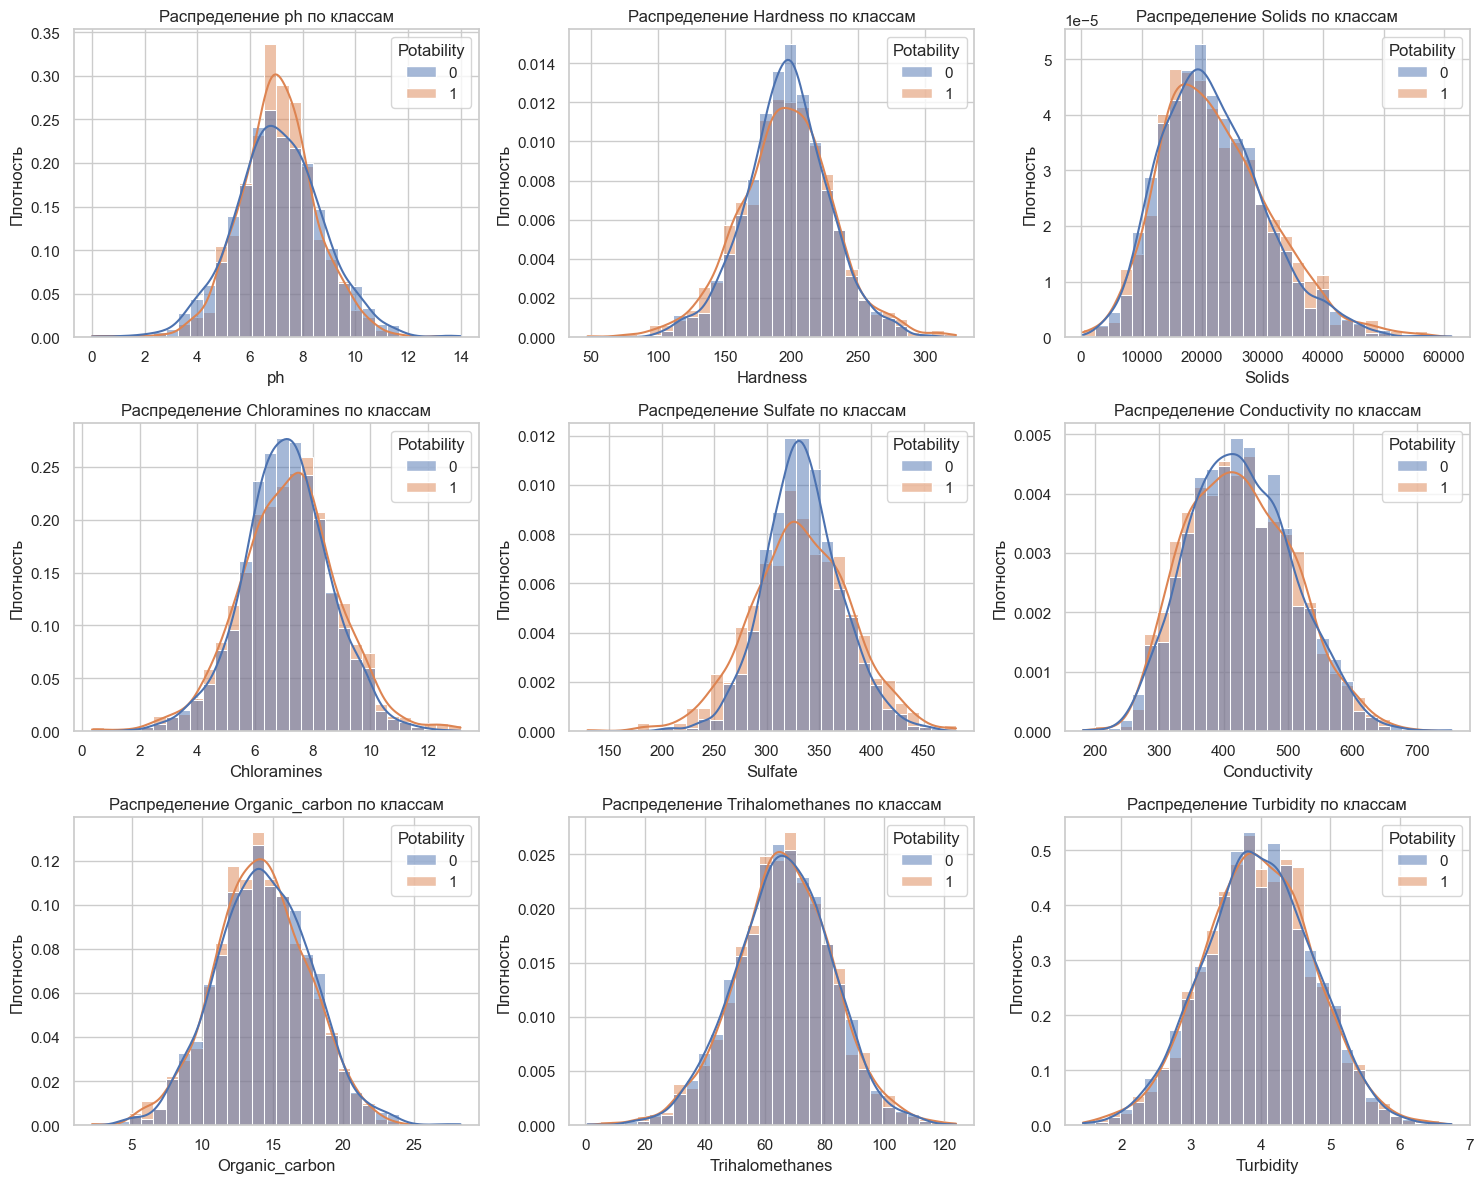

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        bins=30,
        stat="density",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Распределение {col} по классам")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Плотность")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 12. Числовое сравнение признаков по классам

Сравниваем среднее, медиану и стандартное отклонение признаков для каждого класса.

In [14]:
class_feature_summary = (
    df.groupby(target_col)[feature_cols]
    .agg(["mean", "median", "std"])
    .T
)

display(class_feature_summary)

Potability                     0         1
ph              mean       7.085     7.074
                median     7.035     7.037
                std        1.683     1.448
Hardness        mean     196.733   195.801
                median   197.123   196.633
                std       31.058    35.547
Solids          mean   21777.491 22383.991
                median 20809.618 21199.387
                std     8543.069  9101.010
Chloramines     mean       7.092     7.169
                median     7.090     7.215
                std        1.501     1.703
Sulfate         mean     334.564   332.567
                median   333.389   331.838
                std       36.746    47.693
Conductivity    mean     426.730   425.384
                median   422.229   420.713
                std       80.047    82.048
Organic_carbon  mean      14.364    14.161
                median    14.294    14.163
                std        3.335     3.264
Trihalomethanes mean      66.304    66.540
                median    66.542    66.678
                std       16.079    16.327
Turbidity       mean       3.966     3.968
                median     3.948     3.959
                std        0.780     0.781

## 13. Корреляции между признаками

Строим матрицу корреляций Pearson.  
Цель — понять, есть ли сильно связанные признаки и как признаки коррелируют с target.

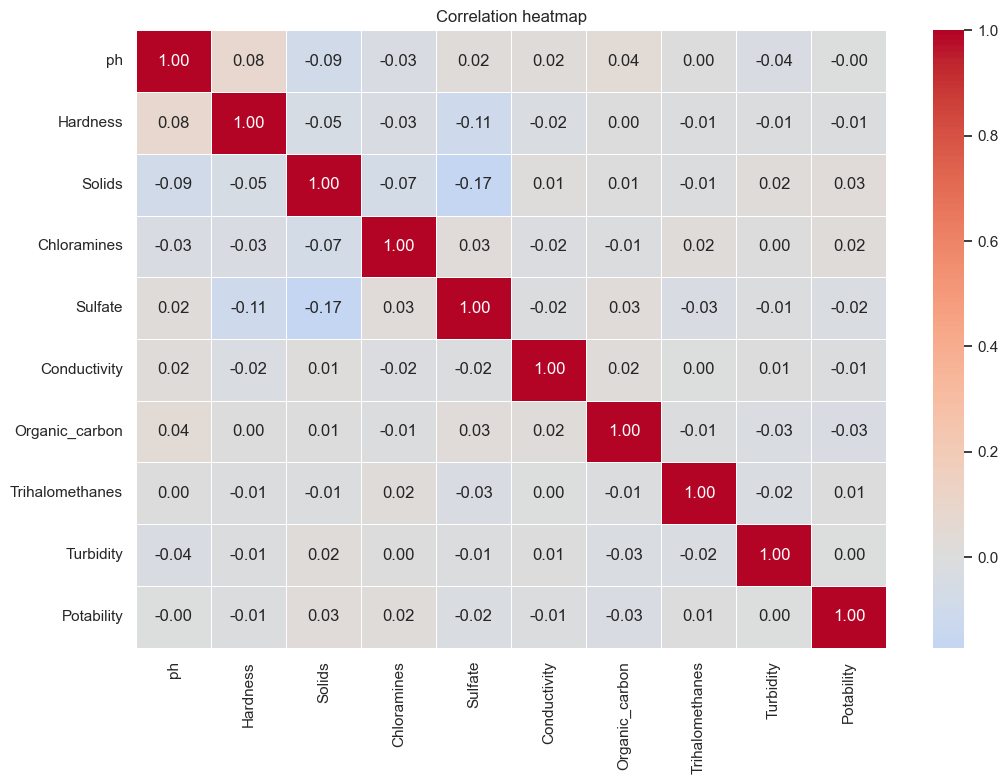

,correlation_with_target
Solids,0.034
Organic_carbon,-0.030
Chloramines,0.024
Sulfate,-0.024
Hardness,-0.014
Conductivity,-0.008
Trihalomethanes,0.007
ph,-0.004
Turbidity,0.002


In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

target_corr = (
    corr[target_col]
    .drop(target_col)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("correlation_with_target")
)

display(target_corr)

## 14. Дополнительная проверка: Spearman correlation

Spearman correlation полезна, если связь монотонная, но не строго линейная.

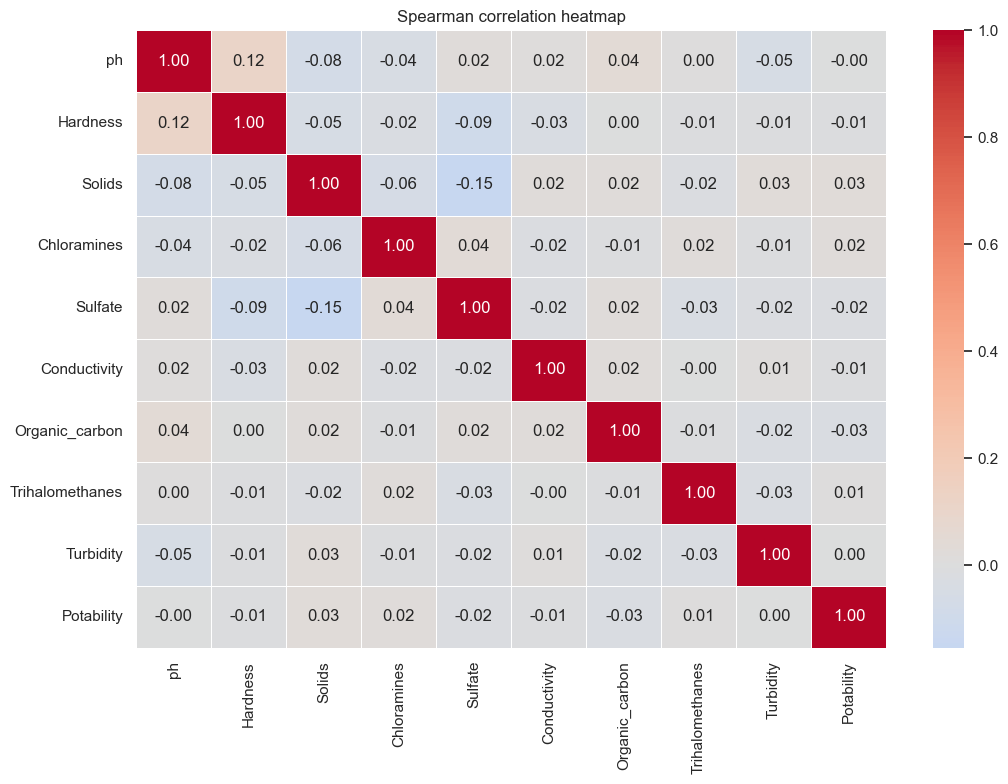

,spearman_correlation_with_target
Organic_carbon,-0.027
Solids,0.026
Chloramines,0.025
Sulfate,-0.017
Hardness,-0.011
Conductivity,-0.010
Trihalomethanes,0.005
ph,-0.002
Turbidity,0.001


In [16]:
spearman_corr = df.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Spearman correlation heatmap")
plt.tight_layout()
plt.show()

spearman_target_corr = (
    spearman_corr[target_col]
    .drop(target_col)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("spearman_correlation_with_target")
)

display(spearman_target_corr)

## 15. Короткий EDA summary

В конце EDA фиксируем практические выводы, которые пойдут в следующий ноутбук с preprocessing и baseline-моделями.

In [17]:
eda_summary = {
    "n_rows": df.shape[0],
    "n_columns": df.shape[1],
    "n_duplicates": int(df.duplicated().sum()),
    "target_positive_share_percent": float(df[target_col].mean() * 100),
    "columns_with_missing_values": missing[missing["missing_count"] > 0].index.tolist(),
}

eda_summary

{'n_rows': 3276,
 'n_columns': 10,
 'n_duplicates': 0,
 'target_positive_share_percent': 39.010989010989015,
 'columns_with_missing_values': ['Sulfate', 'ph', 'Trihalomethanes']}

## Выводы по EDA

В ходе анализа датасета было установлено:

- Датасет содержит 3276 объектов и 9 числовых признаков, дубликаты отсутствуют.
- В данных есть пропуски (`Sulfate`, `ph`, `Trihalomethanes`), при этом они распределены примерно одинаково между классами.
- Целевая переменная умеренно несбалансирована (~39% класса 1).
- Признаки имеют близкие распределения для обоих классов — наблюдается сильное перекрытие.
- Линейные и ранговые корреляции с целевой переменной близки к нулю.

### Главный вывод

Задача не имеет явной линейной структуры: отдельные признаки слабо информативны, а зависимость между признаками и целевой переменной носит **нелинейный характер**.

### Следствие

Для решения задачи необходимо использовать модели, способные учитывать нелинейные зависимости и комбинации признаков (например, деревья и бустинг).
